In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.7/871.7 kB 14.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
from ultralytics import YOLO

def train_yolo():
    # Load a model
    model = YOLO('yolov8n.yaml')  # YOLOv8 nano model, you can change to yolov8s.yaml, yolov8m.yaml, etc.

    # Train the model
    model.train(
        data='/content/drive/MyDrive/gundetection6/dataset.yaml',  # Dataset configuration file
        epochs=50,  # Number of epochs
        imgsz=640,  # Image size
        batch=16,  # Batch size
        name='yolov8_custom'  # Experiment name
    )

if __name__ == '__main__':
    train_yolo()


image 1/170 /content/drive/MyDrive/gundetection6/dataset/images/testwithwhite/image141.jpg: 640x480 1 Gun, 382.6ms
image 2/170 /content/drive/MyDrive/gundetection6/dataset/images/testwithwhite/image142.jpg: 640x480 1 Gun, 216.1ms
image 3/170 /content/drive/MyDrive/gundetection6/dataset/images/testwithwhite/image143.jpg: 640x480 1 Gun, 183.2ms
image 4/170 /content/drive/MyDrive/gundetection6/dataset/images/testwithwhite/image144.jpg: 640x480 1 Gun, 260.8ms
image 5/170 /content/drive/MyDrive/gundetection6/dataset/images/testwithwhite/image145.jpg: 640x480 1 Gun, 277.4ms
image 6/170 /content/drive/MyDrive/gundetection6/dataset/images/testwithwhite/image146.jpg: 640x480 1 Gun, 326.3ms
image 7/170 /content/drive/MyDrive/gundetection6/dataset/images/testwithwhite/image147.jpg: 640x480 1 Gun, 249.9ms
image 8/170 /content/drive/MyDrive/gundetection6/dataset/images/testwithwhite/image148.jpg: 640x480 1 Gun, 266.1ms
image 9/170 /content/drive/MyDrive/gundetection6/dataset/images/testwithwhite/i

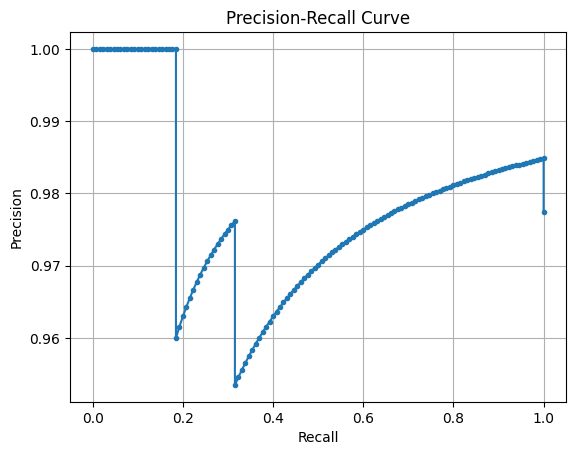

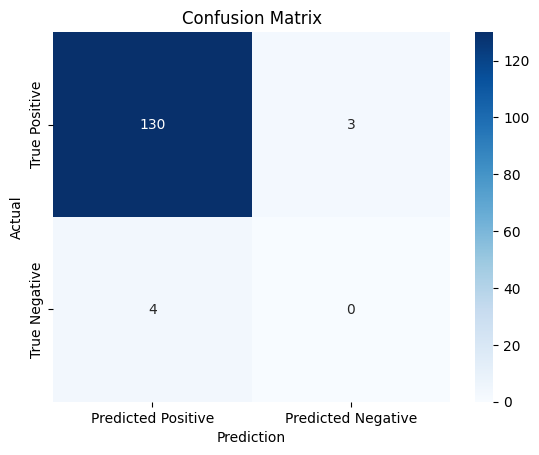

In [ ]:
# Testing with yolo segmentation
# test with background elimination, program for AUC Precision Recall and Confusion matrix
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix
import seaborn as sns

def plot_results(img, boxes, names, save_path, image_name):
    for box in boxes:
        cls = int(box.cls.item())  # Convert class index to an integer
        conf = box.conf.item()  # Convert confidence score to a float
        xyxy = box.xyxy.squeeze().tolist()  # Convert bounding box to a list of integers
        label = names[cls]
        x1, y1, x2, y2 = map(int, xyxy)
        img = cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        img = cv2.putText(img, f'{label} {conf:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

    # Convert BGR to RGB for matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')

    # Save the image
    save_file = os.path.join(save_path, f"{image_name}.png")
    plt.savefig(save_file)
    plt.close()

def read_annotations(annotation_path):
    """
    Reads YOLO format annotations from a file.
    """
    bboxes = []
    with open(annotation_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                raise ValueError(f"Annotation line has an unexpected number of values: {parts}")
            class_id, x_center, y_center, width, height = map(float, parts)
            bboxes.append((class_id, x_center, y_center, width, height))
    return bboxes

def compute_auc_pr(predicted_boxes, ground_truth_boxes, class_count):
    """
    Compute the AUC for the Precision-Recall curve.
    """
    aucs = []
    for class_id in range(class_count):
        true_positives = []
        scores = []
        for pred_box in predicted_boxes:
            if int(pred_box[0]) != class_id:
                continue
            best_iou = 0
            for gt_box in ground_truth_boxes:
                if int(gt_box[0]) != class_id:
                    continue
                iou = calculate_iou(pred_box[1:5], gt_box[1:5])
                if iou > best_iou:
                    best_iou = iou
            true_positives.append(best_iou >= 0.5)
            scores.append(pred_box[4])

        precision, recall, _ = precision_recall_curve(true_positives, scores)
        auc_value = auc(recall, precision)
        aucs.append(auc_value)
    return np.mean(aucs), precision, recall

def compute_confusion_matrix(predicted_boxes, ground_truth_boxes, class_count, iou_threshold=0.5):
    """
    Compute the confusion matrix for object detection, including background.
    """
    tp = np.zeros(class_count + 1, dtype=int)  # +1 for background class
    fp = np.zeros(class_count + 1, dtype=int)
    fn = np.zeros(class_count + 1, dtype=int)
    tn = np.zeros(class_count + 1, dtype=int)

    # Track images with no detections
    images_with_detections = set()
    for box in predicted_boxes:
        image_id = box[-1]  # Assume image_id is stored in the last position of each box
        images_with_detections.add(image_id)

    for class_id in range(class_count + 1):  # Including background class
        gt_boxes = [box[1:5] for box in ground_truth_boxes if int(box[0]) == class_id]
        pred_boxes = [box[1:5] for box in predicted_boxes if int(box[0]) == class_id]
        pred_scores = [box[4] for box in predicted_boxes if int(box[0]) == class_id]

        assigned_gt = []
        for i, pred_box in enumerate(pred_boxes):
            best_iou = 0
            best_gt_idx = -1
            for j, gt_box in enumerate(gt_boxes):
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou and j not in assigned_gt:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_threshold:
                tp[class_id] += 1
                assigned_gt.append(best_gt_idx)
            else:
                fp[class_id] += 1

        fn[class_id] = len(gt_boxes) - len(assigned_gt)

    # True negatives: total number of images - (true positives + false positives + false negatives)
    total_images = len(set(box[-1] for box in ground_truth_boxes).union(set(box[-1] for box in predicted_boxes)))
    tn[class_count] = total_images - sum(tp[:-1] + fp[:-1] + fn[:-1])

    return tp, fp, fn, tn
def convert_to_xyxy(box, img_shape):
    """
    Converts YOLO format box to (x1, y1, x2, y2).
    """
    class_id, x_center, y_center, width, height = box
    h, w = img_shape[:2]
    x_center, y_center, width, height = x_center * w, y_center * h, width * w, height * h
    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2
    return class_id, x1, y1, x2, y2

def calculate_iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) of two bounding boxes.
    """
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area != 0 else 0

def compute_ap(pred_boxes, gt_boxes, class_id, iou_threshold=0.5):
    """
    Compute average precision for a given class.
    """
    true_positives = []
    false_positives = []
    scores = []
    num_gt_boxes = sum(1 for box in gt_boxes if int(box[0]) == class_id)

    for pred_box in pred_boxes:
        if int(pred_box[0]) != class_id:
            continue

        best_iou = 0
        best_gt_idx = -1
        for gt_idx, gt_box in enumerate(gt_boxes):
            if int(gt_box[0]) != class_id:
                continue

            iou = calculate_iou(pred_box[1:5], gt_box[1:5])  # Unpack only 4 values (coordinates)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_threshold:
            true_positives.append(1)
            false_positives.append(0)
        else:
            true_positives.append(0)
            false_positives.append(1)

        scores.append(pred_box[5])  # Ensure score is included

    if num_gt_boxes == 0:
        return 0

    sorted_indices = np.argsort(scores)[::-1]
    true_positives = np.array(true_positives)[sorted_indices]
    false_positives = np.array(false_positives)[sorted_indices]

    cum_tp = np.cumsum(true_positives)
    cum_fp = np.cumsum(false_positives)
    precision = cum_tp / (cum_tp + cum_fp)
    recall = cum_tp / num_gt_boxes

    ap = average_precision_score(true_positives, scores) if num_gt_boxes > 0 else 0
    return ap

def compute_map(predicted_boxes, ground_truth_boxes, class_count, iou_thresholds=[0.5]):
    """
    Compute the mean Average Precision (mAP) across different IoU thresholds.
    """
    aps = {iou_threshold: [] for iou_threshold in iou_thresholds}

    for class_id in range(class_count):
        for iou_threshold in iou_thresholds:
            ap = compute_ap(predicted_boxes, ground_truth_boxes, class_id, iou_threshold)
            aps[iou_threshold].append(ap)

    mean_aps = {iou_threshold: np.mean(aps[iou_threshold]) for iou_threshold in iou_thresholds}
    return mean_aps

def detect_yolo_and_evaluate(source_path, annotations_path, save_path, weights_path, class_count, class_names):
    # Check if weights file exists
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Weight file not found at {weights_path}")

    # Load the model
    model = YOLO(weights_path)

    # Run inference
    results = model(source_path)

    # Create directory to save results if it doesn't exist
    os.makedirs(save_path, exist_ok=True)

    all_pred_boxes = []
    all_gt_boxes = []

    # Visualize results
    for result in results:
        img = result.orig_img  # Get the original image
        boxes = result.boxes  # Get bounding boxes
        image_name = os.path.splitext(os.path.basename(result.path))[0]  # Get image name without extension
        plot_results(img, boxes, result.names, save_path, image_name)

        for box in boxes:
            cls = int(box.cls.item())
            conf = box.conf.item()
            xyxy = box.xyxy.squeeze().tolist()
            all_pred_boxes.append((cls, *xyxy, conf, image_name))

        annotation_file = os.path.join(annotations_path, f"{image_name}.txt")
        if os.path.exists(annotation_file):
            gt_boxes = read_annotations(annotation_file)
            gt_boxes = [convert_to_xyxy(box, img.shape) + (image_name,) for box in gt_boxes]
            all_gt_boxes.extend(gt_boxes)
        else:
            print(f"Warning: No annotation file found for {image_name}")

    # Calculate AUC for Precision-Recall curve
    auc_value, precision, recall = compute_auc_pr(all_pred_boxes, all_gt_boxes, class_count)
    print(f'Precision-Recall AUC: {auc_value:.4f}')

    # Calculate Confusion Matrix
    tp, fp, fn, tn = compute_confusion_matrix(all_pred_boxes, all_gt_boxes, class_count, iou_threshold=0.5)
    #print("Confusion Matrix:")
    #print(f"TP: {tp}")
    #print(f"FP: {fp}")
    #print(f"FN: {fn}")
    #print(f"TN: {tn}")

    for i in range(class_count + 1):  # Including background class
        class_label = class_names[i] if i < class_count else 'background'
        #print(f"Class {class_label} - TP: {tp[i]}, FP: {fp[i]}, FN: {fn[i]}, TN: {tn[i]}")

    # Plotting Precision-Recall curve
    plt.figure()
    plt.plot(recall, precision, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.grid()
    plt.show()

    # Plotting Confusion Matrix
    cm = np.array([[tp[0], fp[0]], [fn[0], tn[0]]])
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Predicted Positive', 'Predicted Negative'], yticklabels=['True Positive', 'True Negative'])
    plt.xlabel('Prediction')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

if __name__ == '__main__':
    # Path to the folder containing images for inference
    source_path = '/content/drive/MyDrive/gundetection6/dataset/images/testwithwhite'
    # Path to save the resulting images
    save_path = '/content/drive/MyDrive/gundetection6/dataset/resultswithwhiteback'
    # Path to the folder containing annotation files
    annotations_path = '/content/drive/MyDrive/gundetection6/dataset/annotations'
    # Path to the weights file
    weights_path = '/content/drive/MyDrive/runs/detect/yolov8_custom/weights/best.pt'
    # Number of classes in the dataset
    class_count = 1  # Set this to the number of classes
    # Class names
    class_names = ["gun"]  # Update this with your class names

    detect_yolo_and_evaluate(source_path, annotations_path, save_path, weights_path, class_count, class_names)


In [ ]:
# Given values
TP = 130
FP = 3
FN = 4
TN = 0

# Calculate metrics
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
accuracy = (TP + TN) / (TP + FP + FN + TN) if (TP + FP + FN + TN) != 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print the results
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1_score:.4f}')


Precision: 0.9774
Recall: 0.9701
Accuracy: 0.9489
F1 Score: 0.9738
